# Финальный проект по анализу временных рядов

Задача: по 4000 зашумленным наблюдениям (200 с) спрогнозировать чистый сигнал на горизонте 1000 точек (50 с, $\Delta t = 0.05$).

В проекте последовательно выполняются следующие шаги:
1. предобработка и сглаживание входного ряда;
2. формирование признаков для модели;
3. обучение модели прогноза;
4. расчет метрик качества и сравнение с базовыми решениями;
5. визуальный анализ ошибок, RMSE по шагам и поведения на горизонте.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

In [2]:
DT = 0.05
INPUT_LEN = 4000
HORIZON = 1000

train_noisy = pd.read_csv('final_project/train.csv', header=None).values.astype(np.float32)
test_noisy = pd.read_csv('final_project/test.csv', header=None).values.astype(np.float32)
train_clean_full = pd.read_csv('final_project/etalon_for_train.csv', header=None).values.astype(np.float32)
test_clean_full = pd.read_csv('final_project/etalon_for_test.csv', header=None).values.astype(np.float32)

X_train_noisy = train_noisy[:, :INPUT_LEN]
X_test_noisy = test_noisy[:, :INPUT_LEN]

X_train_clean = train_clean_full[:, :INPUT_LEN]
X_test_clean = test_clean_full[:, :INPUT_LEN]

y_train_clean = train_clean_full[:, INPUT_LEN:INPUT_LEN + HORIZON]
y_test_clean = test_clean_full[:, INPUT_LEN:INPUT_LEN + HORIZON]

print('Train noisy:', X_train_noisy.shape)
print('Train clean past:', X_train_clean.shape)
print('Train clean future:', y_train_clean.shape)
print('Test noisy:', X_test_noisy.shape)
print('Test clean future:', y_test_clean.shape)

Train noisy: (1000, 4000)
Train clean past: (1000, 4000)
Train clean future: (1000, 1000)
Test noisy: (500, 4000)
Test clean future: (500, 1000)


In [3]:
def denoise_batch(data_2d: np.ndarray, window_length: int, polyorder: int = 3) -> np.ndarray:
    return savgol_filter(data_2d, window_length=window_length, polyorder=polyorder, axis=1).astype(np.float32)

candidate_windows = [11, 21, 31, 41, 61, 81]
best_window = None
best_mse = np.inf

for w in candidate_windows:
    den = denoise_batch(X_train_noisy, window_length=w, polyorder=3)
    mse = mean_squared_error(X_train_clean.reshape(-1), den.reshape(-1))
    if mse < best_mse:
        best_mse = mse
        best_window = w

X_train_denoised = denoise_batch(X_train_noisy, window_length=best_window, polyorder=3)
X_test_denoised = denoise_batch(X_test_noisy, window_length=best_window, polyorder=3)

print(f'Best denoising window: {best_window}')
print(f'Denoising MSE on train past: {best_mse:.6f}')

Best denoising window: 81
Denoising MSE on train past: 0.009431


In [4]:
def extract_features(series_2d: np.ndarray, n_fft: int = 128, downsample_step: int = 40) -> np.ndarray:
    fft_amp = np.abs(np.fft.rfft(series_2d, axis=1))[:, 1:n_fft + 1]
    ds = series_2d[:, ::downsample_step]
    mean_ = series_2d.mean(axis=1, keepdims=True)
    std_ = series_2d.std(axis=1, keepdims=True)
    slope_ = (series_2d[:, -1] - series_2d[:, 0]).reshape(-1, 1)
    return np.hstack([fft_amp, ds, mean_, std_, slope_]).astype(np.float32)

X_train_feat = extract_features(X_train_denoised)
X_test_feat = extract_features(X_test_denoised)

print('Feature matrix train:', X_train_feat.shape)
print('Feature matrix test:', X_test_feat.shape)

Feature matrix train: (1000, 231)
Feature matrix test: (500, 231)


In [5]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=7, weights='distance', metric='euclidean', n_jobs=-1)),
])

model.fit(X_train_feat, y_train_clean)
y_pred = model.predict(X_test_feat).astype(np.float32)

print('Prediction shape:', y_pred.shape)

Prediction shape: (500, 1000)


In [6]:
# Базовый прогноз 1: перенос последнего наблюденного значения
last_points = X_test_noisy[:, -1].reshape(-1, 1)
naive_point = np.repeat(last_points, HORIZON, axis=1).astype(np.float32)

# Базовый прогноз 2: среднее по последним 1000 наблюдениям
past_mean = X_test_noisy[:, -1000:].mean(axis=1, keepdims=True)
mean_baseline = np.repeat(past_mean, HORIZON, axis=1).astype(np.float32)

errors = y_pred - y_test_clean
errors_naive = naive_point - y_test_clean
errors_mean = mean_baseline - y_test_clean

# Обязательные метрики проекта
mean_error_per_step = errors.mean(axis=0)
rmse_per_step = np.sqrt((errors ** 2).mean(axis=0))

# Дополнительные метрики для полного сравнения с готовым примером
rmse_naive_per_step = np.sqrt((errors_naive ** 2).mean(axis=0))
rmse_mean_per_step = np.sqrt((errors_mean ** 2).mean(axis=0))

mse_denoise = mean_squared_error(X_test_clean.reshape(-1), X_test_denoised.reshape(-1))
mse_model = mean_squared_error(y_test_clean.reshape(-1), y_pred.reshape(-1))
mse_naive = mean_squared_error(y_test_clean.reshape(-1), naive_point.reshape(-1))
mse_mean = mean_squared_error(y_test_clean.reshape(-1), mean_baseline.reshape(-1))
rmse_total = np.sqrt(mse_model)
mae_total = mean_absolute_error(y_test_clean.reshape(-1), y_pred.reshape(-1))

print('=== Метрики на тесте (модель + базовые прогнозы) ===')
print(f'MSE сглаживания (прошлая часть): {mse_denoise:.6f}')
print(f'MSE прогноза модели:          {mse_model:.6f}')
print(f'MSE наивного точечного:       {mse_naive:.6f}')
print(f'MSE baseline по среднему:     {mse_mean:.6f}')
print(f'RMSE прогноза модели:         {rmse_total:.6f}')
print(f'MAE прогноза модели:          {mae_total:.6f}')
print(f'RMSE h=1:                     {rmse_per_step[0]:.6f}')
print(f'RMSE h={HORIZON}:                  {rmse_per_step[-1]:.6f}')


=== Метрики на тесте (модель + базовые прогнозы) ===
MSE сглаживания (прошлая часть): 0.009453
MSE прогноза модели:          0.295275
MSE наивного точечного:       0.841165
MSE baseline по среднему:     0.274066
RMSE прогноза модели:         0.543392
MAE прогноза модели:          0.434574
RMSE h=1:                     0.474916
RMSE h=1000:                  0.562676


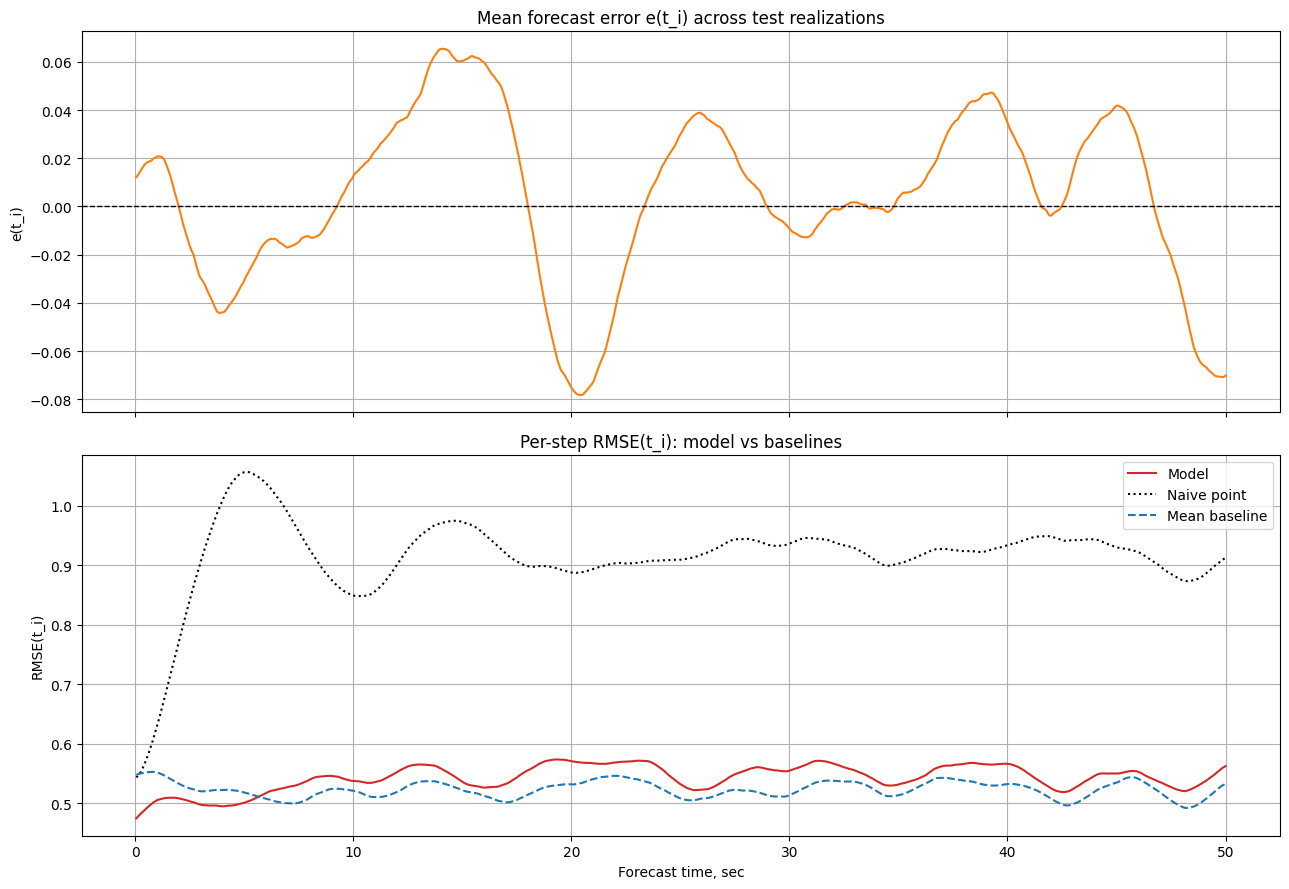

In [7]:
h = np.arange(1, HORIZON + 1)
time_future = h * DT

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(time_future, mean_error_per_step, color='tab:orange')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Mean forecast error e(t_i) across test realizations')
axes[0].set_ylabel('e(t_i)')

axes[1].plot(time_future, rmse_per_step, color='tab:red', label='Model')
axes[1].plot(time_future, rmse_naive_per_step, color='black', linestyle=':', label='Naive point')
axes[1].plot(time_future, rmse_mean_per_step, color='tab:blue', linestyle='--', label='Mean baseline')
axes[1].set_title('Per-step RMSE(t_i): model vs baselines')
axes[1].set_xlabel('Forecast time, sec')
axes[1].set_ylabel('RMSE(t_i)')
axes[1].legend()

plt.tight_layout()
plt.show()

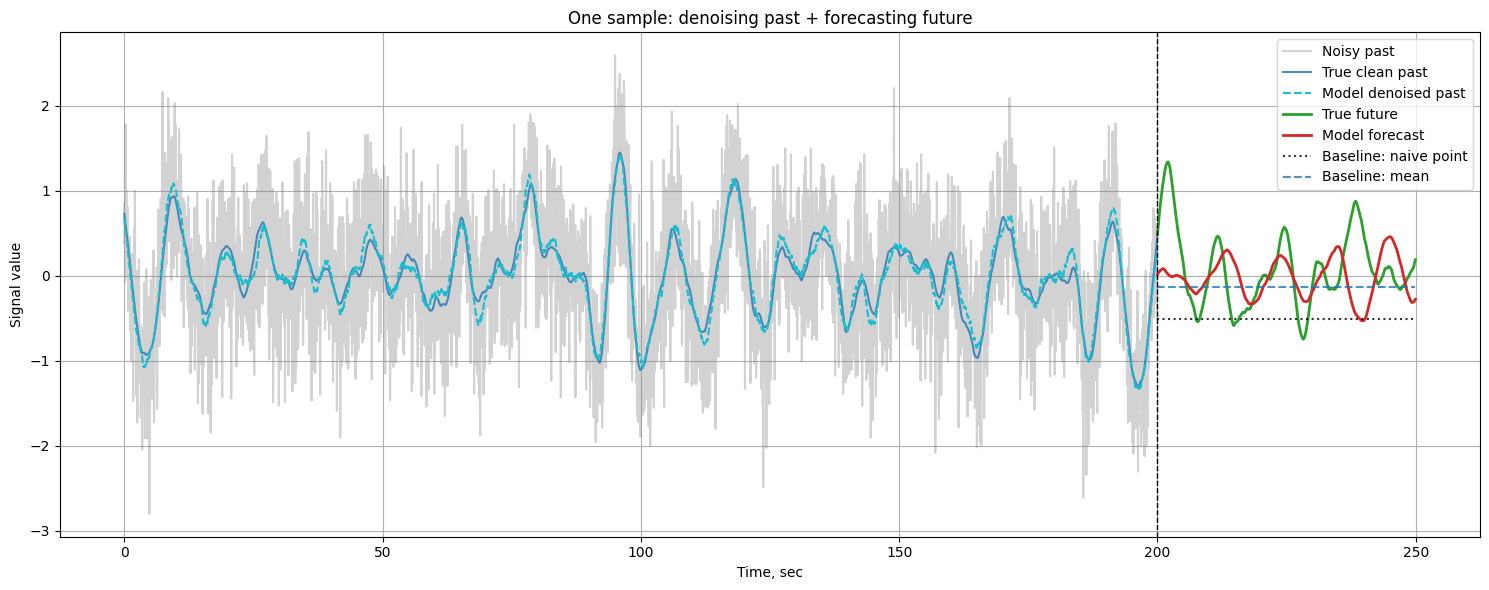

In [8]:
idx = 0
past_t = np.arange(INPUT_LEN) * DT
future_t = np.arange(INPUT_LEN, INPUT_LEN + HORIZON) * DT

plt.figure(figsize=(15, 6))
plt.plot(past_t, X_test_noisy[idx], color='gray', alpha=0.35, label='Noisy past')
plt.plot(past_t, X_test_clean[idx], color='tab:blue', alpha=0.8, label='True clean past')
plt.plot(past_t, X_test_denoised[idx], color='tab:cyan', linestyle='--', label='Model denoised past')

plt.plot(future_t, y_test_clean[idx], color='tab:green', linewidth=2, label='True future')
plt.plot(future_t, y_pred[idx], color='tab:red', linewidth=2, label='Model forecast')
plt.plot(future_t, naive_point[idx], color='black', linestyle=':', alpha=0.8, label='Baseline: naive point')
plt.plot(future_t, mean_baseline[idx], color='tab:blue', linestyle='--', alpha=0.8, label='Baseline: mean')

plt.axvline(INPUT_LEN * DT, color='black', linestyle='--', linewidth=1)
plt.title('One sample: denoising past + forecasting future')
plt.xlabel('Time, sec')
plt.ylabel('Signal value')
plt.legend()
plt.tight_layout()
plt.show()

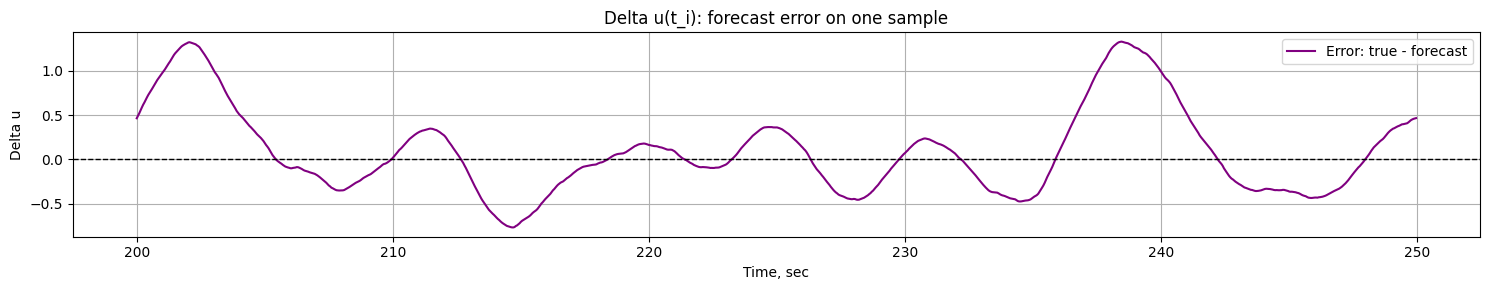

In [9]:
idx = 0
delta_u = y_test_clean[idx] - y_pred[idx]

plt.figure(figsize=(15, 3))
plt.plot(future_t, delta_u, color='purple', label='Error: true - forecast')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Delta u(t_i): forecast error on one sample')
plt.xlabel('Time, sec')
plt.ylabel('Delta u')
plt.legend()
plt.tight_layout()
plt.show()

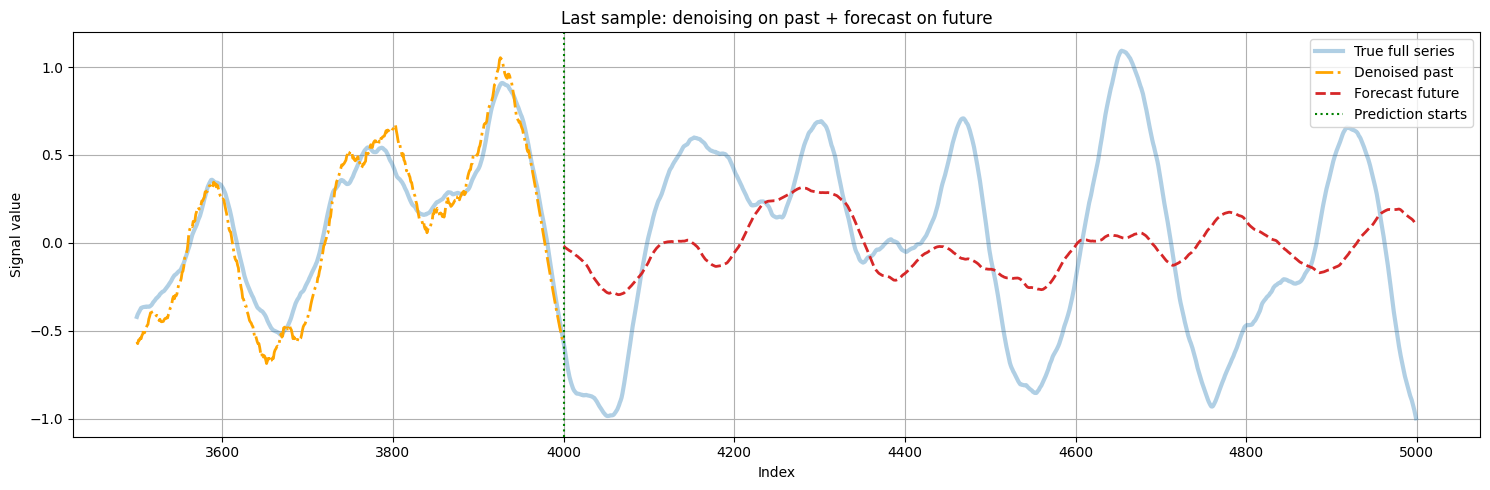

RMSE h=1: 0.474916
RMSE h=1000: 0.562676


In [10]:
steps_to_generate = HORIZON
seed_len = INPUT_LEN
total_len = INPUT_LEN + HORIZON

view_count = 1500
start_view = total_len - view_count
indices = np.arange(start_view, total_len)

idx_to_plot = -1
last_sample_true = test_clean_full[idx_to_plot]
last_preds_future = y_pred[idx_to_plot]
last_preds_past = X_test_denoised[idx_to_plot]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(indices, last_sample_true[start_view:], color='tab:blue', alpha=0.35, lw=3, label='True full series')
ax.plot(np.arange(start_view, seed_len), last_preds_past[start_view:], color='orange', linestyle='-.', lw=2, label='Denoised past')
ax.plot(np.arange(seed_len, total_len), last_preds_future, color='tab:red', linestyle='--', lw=2, label='Forecast future')
ax.axvline(x=seed_len, color='green', linestyle=':', label='Prediction starts')
ax.set_title('Last sample: denoising on past + forecast on future')
ax.set_xlabel('Index')
ax.set_ylabel('Signal value')
ax.legend()
plt.tight_layout()
plt.show()

print(f'RMSE h=1: {rmse_per_step[0]:.6f}')
print(f'RMSE h={steps_to_generate}: {rmse_per_step[-1]:.6f}')